# EDA sur le dataset Iris, Exercice

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load le Dataset

In [3]:
df = pd.read_csv("iris.csv")
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 2. Afficher les informations 

In [6]:
display(df.info())
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


None

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


Analyse :
Je remarque que toutes mes données sont de type numérique, mais attention cela ne veut pas dire qu'elles ne sont pas catégoriques ou autre.
Le min et max de mes features Semblent correcte par rapport la moyenne et la médianne donc pas de valeurs abhérente apparante.

## 2a. je vais faire un value count pour en apprendre plus sur le type de données que sont chacune de mes colonnes

In [17]:
for col in df.columns:
    display(df[col].value_counts())

sepal length (cm)
5.0    10
5.1     9
6.3     9
5.7     8
6.7     8
5.8     7
5.5     7
6.4     7
4.9     6
5.4     6
6.0     6
6.1     6
5.6     6
4.8     5
6.5     5
4.6     4
5.2     4
6.9     4
6.2     4
7.7     4
4.4     3
5.9     3
6.8     3
7.2     3
4.7     2
6.6     2
4.3     1
4.5     1
5.3     1
7.0     1
7.1     1
7.6     1
7.3     1
7.4     1
7.9     1
Name: count, dtype: int64

sepal width (cm)
3.0    26
2.8    14
3.2    13
3.4    12
3.1    11
2.9    10
2.7     9
2.5     8
3.5     6
3.8     6
3.3     6
2.6     5
3.6     4
2.3     4
3.7     3
2.4     3
2.2     3
3.9     2
4.0     1
4.4     1
4.1     1
4.2     1
2.0     1
Name: count, dtype: int64

petal length (cm)
1.4    13
1.5    13
4.5     8
5.1     8
1.3     7
1.6     7
5.6     6
4.7     5
4.9     5
4.0     5
1.7     4
4.2     4
4.4     4
4.8     4
5.0     4
4.6     3
3.9     3
4.1     3
5.8     3
6.1     3
5.5     3
5.7     3
1.2     2
1.9     2
3.3     2
3.5     2
4.3     2
6.0     2
5.9     2
5.3     2
6.7     2
5.4     2
5.2     2
1.1     1
1.0     1
3.6     1
3.8     1
3.7     1
3.0     1
6.6     1
6.3     1
6.9     1
6.4     1
Name: count, dtype: int64

petal width (cm)
0.2    29
1.3    13
1.5    12
1.8    12
1.4     8
2.3     8
0.4     7
0.3     7
1.0     7
2.1     6
2.0     6
0.1     5
1.2     5
1.9     5
1.6     4
1.1     3
2.5     3
2.2     3
2.4     3
1.7     2
0.5     1
0.6     1
Name: count, dtype: int64

target
0    50
1    50
2    50
Name: count, dtype: int64


## 3. Cherchons les valeurs nulles

In [10]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Aucune valeur nulle

## 4. Comprenons les features et identifions la target

- Ici c'est relativement simple, un nom de colonne s'appelle target.
- J'aimerais comprendre à quoi elle correspond

je vais donc vérifier les valeurs unique de cette colonne

In [11]:
df["target"].unique()

array([0, 1, 2])

Je remarque 3 valeurs unique dans ma target, elles correspondent à des type de fleur Iris, le sens de mes données ici est donc quel : la longueur et la largeur des pétales / sépales = ce type d'Iris

## 5. Mettons en place les graphiques pour une analyse plus complète et visuelle

D'abord j'aimerais différencier mes features selon leurs type de data :
- Toutes mes features sont en cm, ce sont donc des données quantitatives continues

- Ma target est composé de 3 valeurs unique et détermine une classe / un type d'Iris donc ce sont des données qualitatives nominales

=> Séparons nos datas (sans tenir compte de feature et target)

In [19]:
data_continues = df.drop(columns=["target"])
data_nominales = df[["target"]]
display(data_nominales.head())
data_continues.head()

,target
0,0
1,0
2,0
3,0
4,0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 6. Passons à l'analyse univariée

### 6.1 Univariée des continues
Analysons les distributions

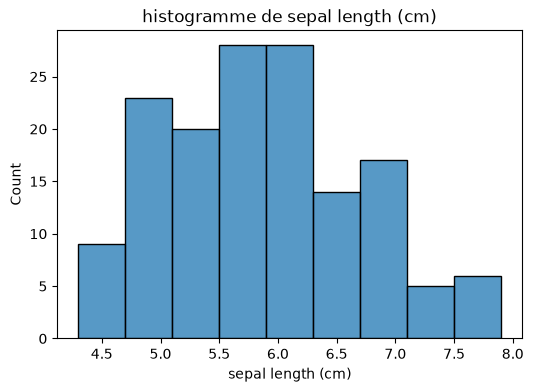

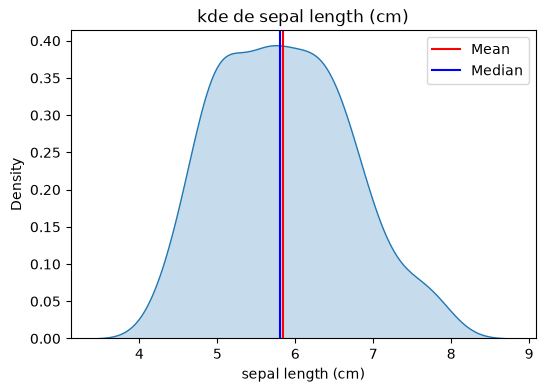

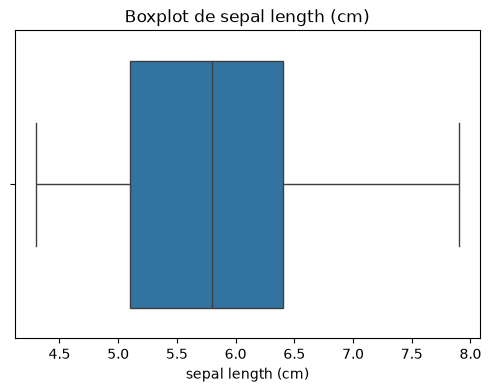

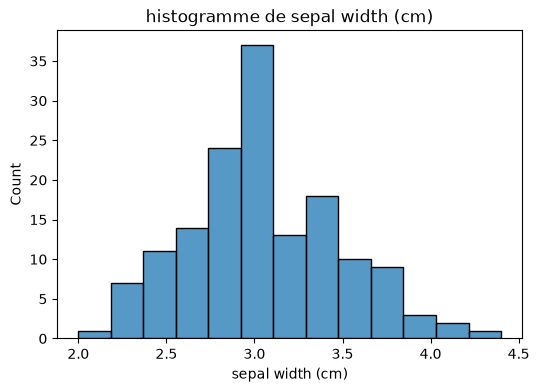

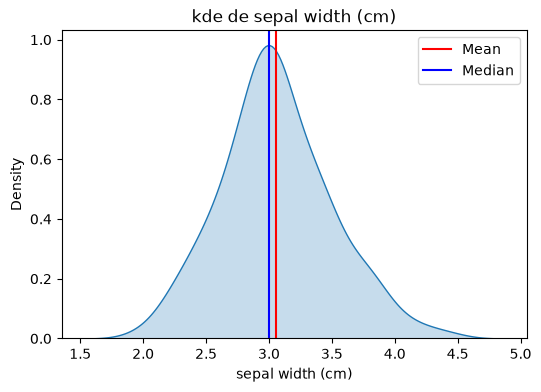

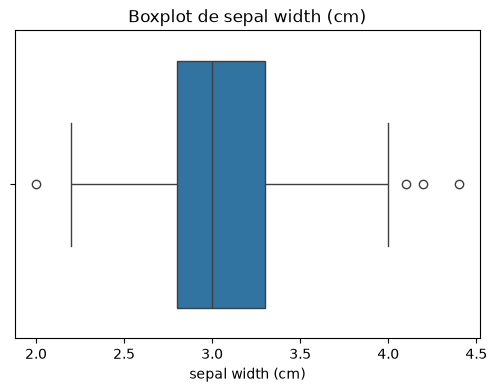

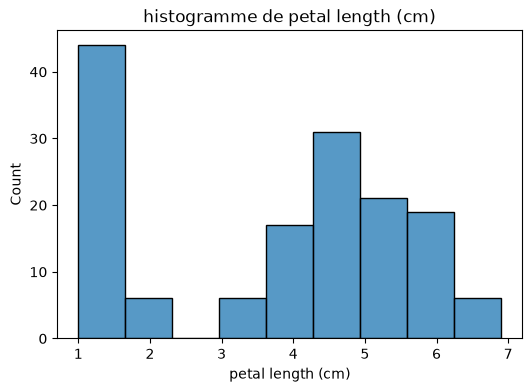

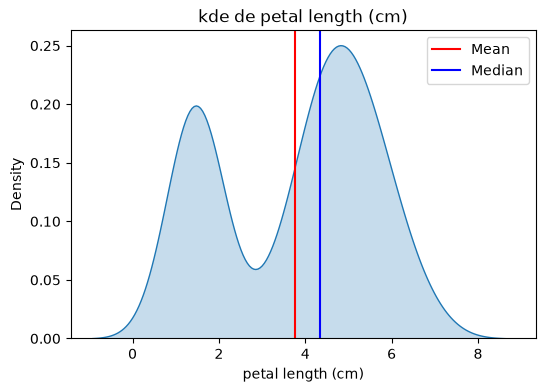

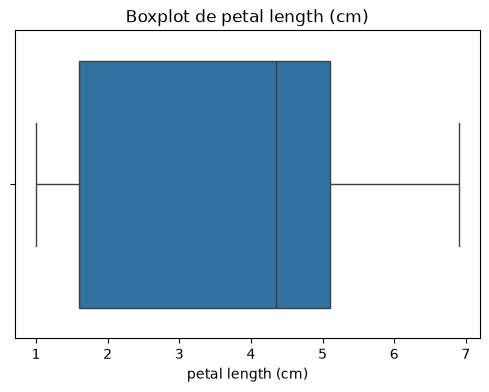

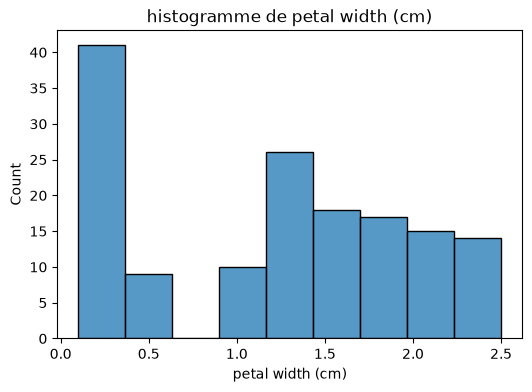

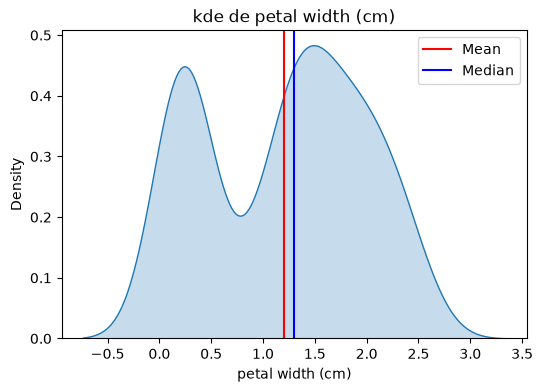

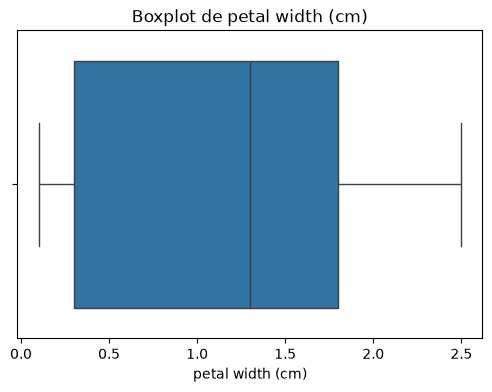

In [23]:
for col in data_continues.columns :
    # Histogramme
    plt.figure(figsize=(6,4))
    plt.title(f"histogramme de {col}")
    sns.histplot(data=data_continues,x=col)
    plt.show()

    # kde
    plt.figure(figsize=(6,4))
    plt.title(f"kde de {col}")
    sns.kdeplot(data=data_continues,x=col,fill=True)
    plt.axvline(x=data_continues[col].mean(),c="red",label="Mean") # Affichage de la moyenne
    plt.axvline(x=data_continues[col].median(),c="blue",label="Median") # Affichage de la médianne de la colonne
    plt.legend()
    plt.show() 

    # Boxplot
    plt.figure(figsize=(6,4))
    plt.title(f"Boxplot de {col}")
    sns.boxplot(data=data_continues,x=col)
    plt.show()

#### 6.1.1 Interpretation et Analyse des graphs

Rien de trop anormal,

- Bimodalité sur le kde de petal lenght et petal width (à l'air d'avoir du sens ici cependant on distingue 3 différnetes catégories de target et on y trouve seulement 2 pics de distribution)
- Boxplot de petal lenght, je trouve la médiane fort proche du 3ème quartile

### 6.2 Analyse univariée catégoriques

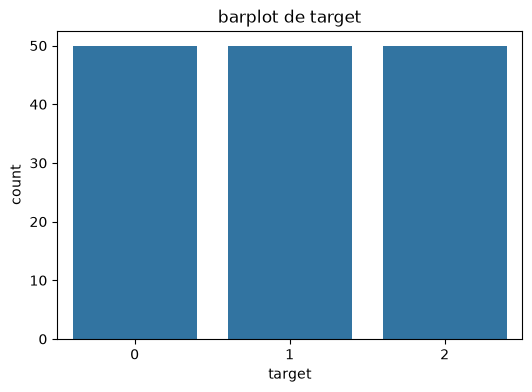

target
0    50
1    50
2    50
Name: count, dtype: int64

In [24]:
plt.figure(figsize=(6,4))
plt.title("barplot de target")
sns.countplot(data=data_nominales,x='target')
plt.show()
df['target'].value_counts()

#### 6.2.1 Interprétation et analyse des graphs

Ici ma seule donnée catégorique est ma target, on y retoruve une distribution parfaite entre les 3 types, assez bonne nouvelle, pas de gros écarts entre la quantité de mes types target

## 7. Analyse Bivariée

On projette tout sur target

------------------------- sepal length (cm) -------------------------


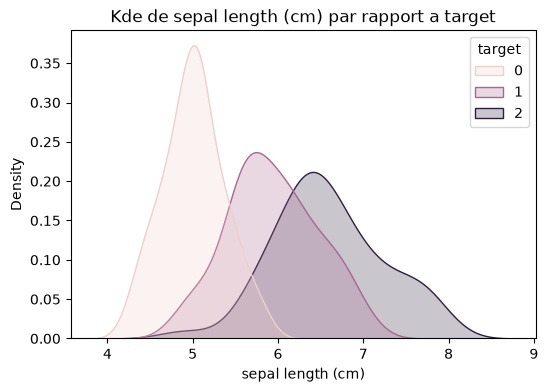

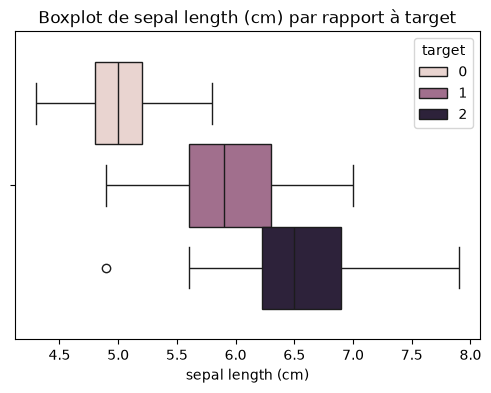







------------------------- sepal width (cm) -------------------------


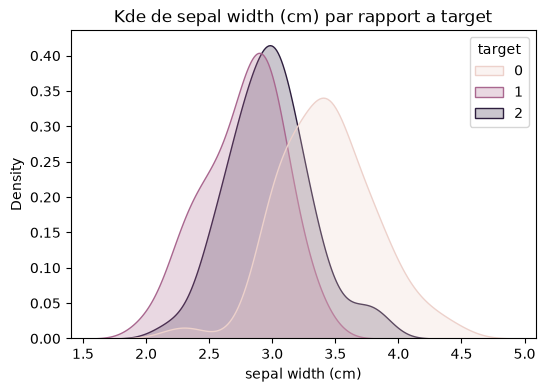

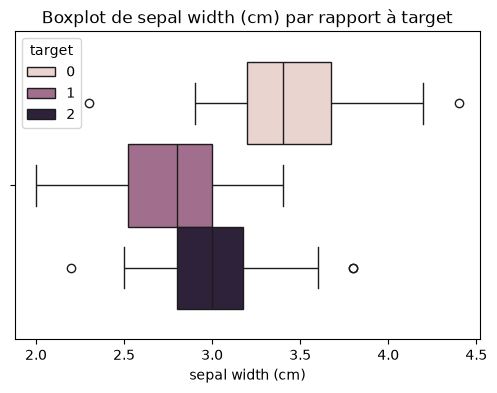







------------------------- petal length (cm) -------------------------


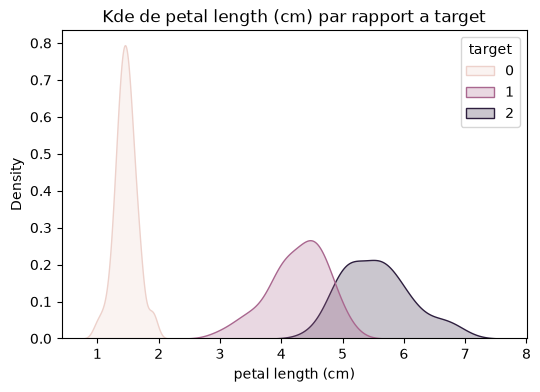

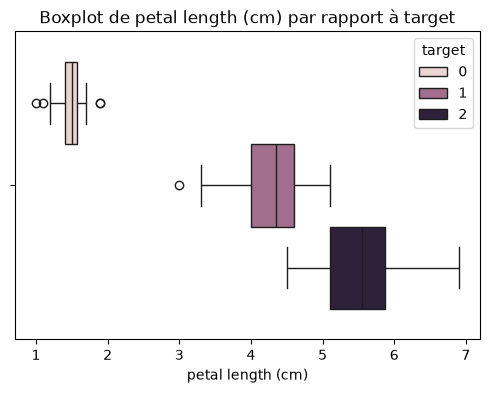







------------------------- petal width (cm) -------------------------


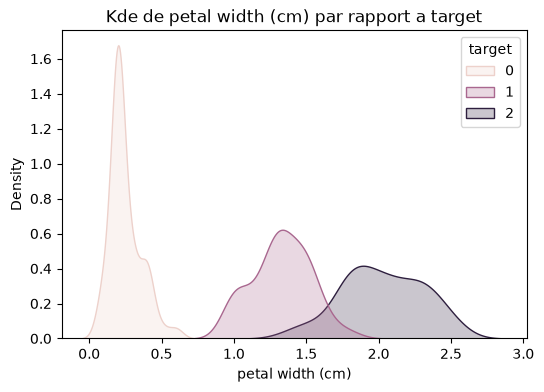

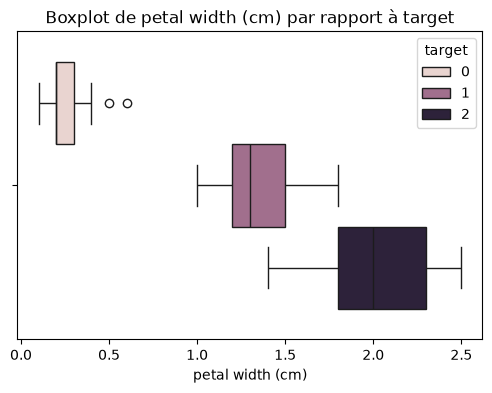

In [30]:
for col in data_continues.columns :
    print(25*'-',col,25*'-')
    # Kde
    plt.figure(figsize=(6,4))
    plt.title(f"Kde de {col} par rapport a target")
    sns.kdeplot(data=data_continues,x=col, fill=True,hue=df['target']) # Le paramètre hue permet de "ventiler" la distribution
    plt.show()

    # Boxplot
    plt.figure(figsize=(6,4))
    plt.title(f"Boxplot de {col} par rapport à target")
    sns.boxplot(data=data_continues,x=col,hue=df["target"])
    plt.show()

    print(5*"\n")

#### 7.1 Interprétation et analyse des graphs

La target 0 se différencie beaucoup plus des deux autres, elle à très souvent des distances plus courte.

La largeur et longueur des pétales se distinguent, selon la longueur, elle permettent de différencier clairement le type de target 

## 8. Analyse multivariée

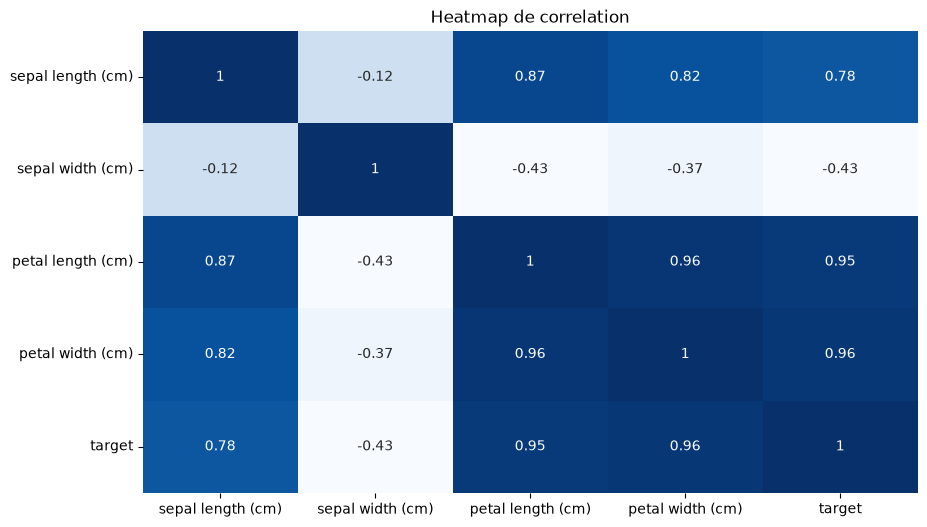

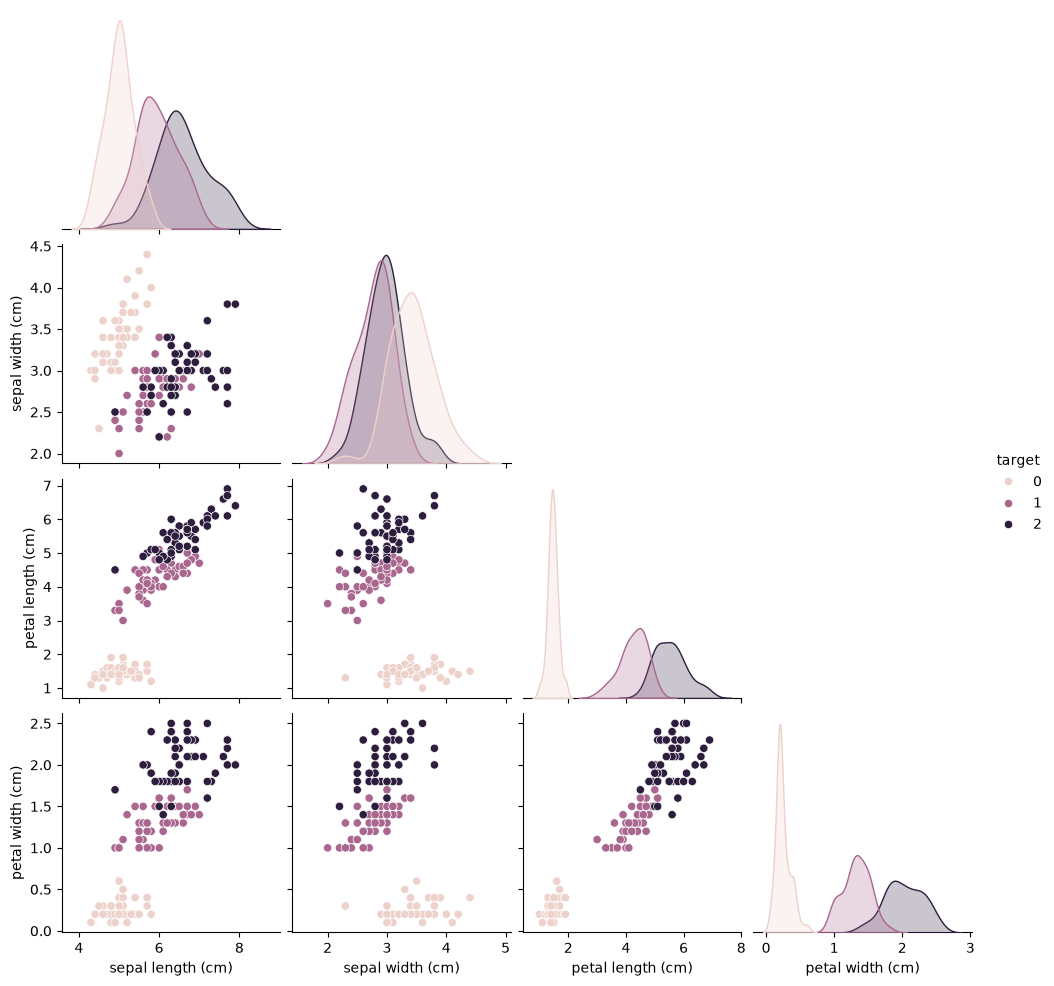

In [33]:
plt.figure(figsize=(10,6))
plt.title("Heatmap de correlation")
sns.heatmap(df.corr(numeric_only=True),cbar=False,annot=True,fmt='.2g',cmap="Blues")
plt.show()

sns.pairplot(data=df,hue='target',corner=True)

#### 8.1 Analyse